In [125]:
from contextlib import contextmanager
import time

@contextmanager
def timer(name):
    t0 = time.time()
    yield
    print(f"[{name}] done in {(time.time() - t0) * 1000:.1f} msec")

In [126]:
from pathlib import Path
import time
import random
import os
import numpy as np

# Env

In [127]:
def is_out_of_range(y: int, x: int, N:int)->bool:
    return not ((0 <= x < N) and (0 <= y < N))

In [128]:
def calc_mu_sigma(k:int, e:float, vs:int):
    mu = (k-vs)*e + vs*(1-e)
    sigma = k*e*(1-e)
    return mu, sigma

In [129]:
class Env:
    IS_OUTPUT_FILE = True

    def __init__(self, file_path: str, exp_num: int):
        with open(file_path, mode="r") as f:
            lines = f.readlines()
            N, M, ESP = lines[0].split()
            N, M, ESP = int(N), int(M), float(ESP)
            GRID = []
            lines = lines[1:]
            for _line in lines[:M]:
                _line = _line.split()
                ps = []
                for i in range(int(_line[0])):
                    ps.append((int(_line[2 * i + 1]), int(_line[2 * i + 2])))
                GRID.append(ps)
            lines = lines[2 * M :]
            ANS_GRID = []
            for _line in lines[:N]:
                ANS_GRID.append(list(map(int, _line.split())))

        self.N: int = N
        self.M: int = M
        self.esp: float = ESP
        self.grids: list[list[tuple[int, int]]] = GRID
        self.ans_grid: list[list[int]] = ANS_GRID

        self.total_oil_num: int = sum(len(g) for g in self.grids)
        self.score: int = 10**9

        cnt: int = 0
        for y in range(N):
            for x in range(N):
                if self.ans_grid[y][x] > 0:
                    cnt += 1
        self.ans_point_size: int = cnt

        self._sum_oil: int = 0
        self._score: float = 0

        self.plus_coordinates: list[tuple[int, int]] = []

        self.fixed_board: list[list[int]] = [[-1 for _ in range(N)] for _ in range(N)]

        self.queries1: list[tuple[tuple[int, int], int]] = []
        self.queries2: list[tuple[tuple[int, int], int]] = []
        
        self._out_file_path: Path = Path(f"../out/out{exp_num:0>4}.txt")
        if Env.IS_OUTPUT_FILE:
            if self._out_file_path.exists():
                os.remove(self._out_file_path)
            self._out_file_path.touch()

    def is_ok(self):
        return self._sum_oil == self.total_oil_num

    def query1(self, coordinate) -> int:
        y, x = coordinate
        self._score += 1
        resp: int = self.ans_grid[y][x]
        self.queries1.append((coordinate, resp))
        self.fixed_board[y][x] = resp
        if resp > 0:
            self._sum_oil += resp
            self.plus_coordinates.append(coordinate)
        if Env.IS_OUTPUT_FILE:
            q = "q 1 {} {}".format(coordinate[0], coordinate[1])
            with open(self._out_file_path, mode="+a") as f:
                f.write(q + "\n")
        return resp

    def query2(self, coordinates):
        k = len(coordinates)
        vs = sum(self.ans_grid[y][x] for y, x in coordinates)
        mu, sigma = calc_mu_sigma(k, self.esp, vs)
        rng = np.random.default_rng()
        resp = max(0, round(rng.normal(mu, sigma)))
        self._score += 1 / np.sqrt(k)
        self.queries2.append(resp)
        if Env.IS_OUTPUT_FILE:
            coordinate = []
            for y, x in coordinates:
                coordinate.append(y)
                coordinate.append(x)
            q = f"q {len(coordinates)} " + " ".join(map(str, coordinate))
            with open(self._out_file_path, mode="+a") as f:
                f.write(q + "\n")
        return resp
    
    def answer(self, coordinates) -> bool:
        is_ok = self.total_oil_num == sum(self.ans_grid[y][x] for y, x in coordinates)
        if is_ok:
            self.score = self._score
        else:
            self._score += 1
        if Env.IS_OUTPUT_FILE:
            q = "a {} {}".format(len(coordinates), " ".join(map(lambda k: "{} {}".format(k[0], k[1]), coordinates)))
            with open(self._out_file_path, mode="+a") as f:
                f.write(q + "\n")
        return is_ok

    def answer_from_board(self, board: list[list[int]]) -> bool:
        has_oils: list[tuple[int, int]] = []
        for y in range(self.N):
            for x in range(self.N):
                if board[y][x] > 0:
                    has_oils.append((y, x))
        return self.answer(has_oils)

    @property
    def query1_count(self) -> int:
        return len(self.queries1)

# Run

In [130]:
env = Env(file_path = Path(f"../in/{0:0>4}.txt"), exp_num=0)

In [131]:
def search_placement_indexes(env: Env) -> list[list[tuple[int, int]]]:

    N: int = env.N
    M: int = env.M
    f_board: list[list[int]] = env.fixed_board
    grids: list[list[tuple[int, int]]] = env.grids

    placement_indexes: list[list[tuple[int, int]]] = []
    for m in range(M):
        now_grids: list[tuple[int, int]] = grids[m]
        now_placement_indexes: list[tuple[int, int]] = []
        is_m_indexes: list[tuple[int, int]] = []
        for y in range(N):
            for x in range(N):
                flag: bool = True
                max_diff = -1
                for coordinate in now_grids:
                    ny, nx = y + coordinate[0], x + coordinate[1]
                    if is_out_of_range(ny, nx, N) or f_board[ny][nx] == 0:
                        flag = False
                        break
                    max_diff = max(max_diff, f_board[ny][nx])
                if flag:
                    now_placement_indexes.append((y, x))
                    if max_diff == M:
                        is_m_indexes.append((y, x))
        if len(is_m_indexes) > 0:
            now_placement_indexes = is_m_indexes
        placement_indexes.append(now_placement_indexes)

    return placement_indexes

In [132]:
N = env.N
cnt_board = [[env.total_oil_num / N**2 for _ in range(N)] for _ in range(N)]

In [133]:
def get_all_coordinate(env: Env):
    all_coordinates = []
    for y in range(N):
        for x in range(N):
            if env.fixed_board[y][x] == -1:
                all_coordinates.append((y, x))
    return all_coordinates

In [134]:
import matplotlib.pyplot as plt

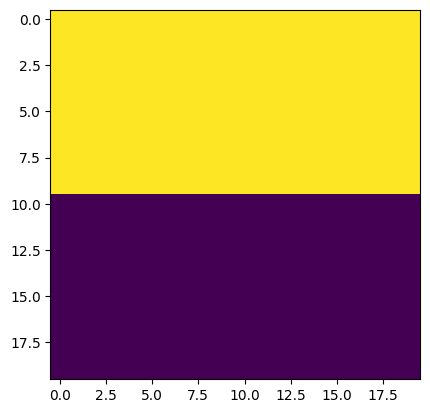

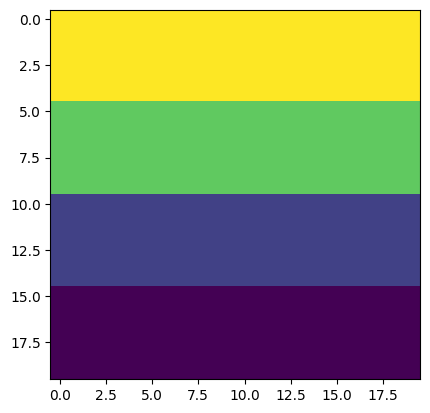

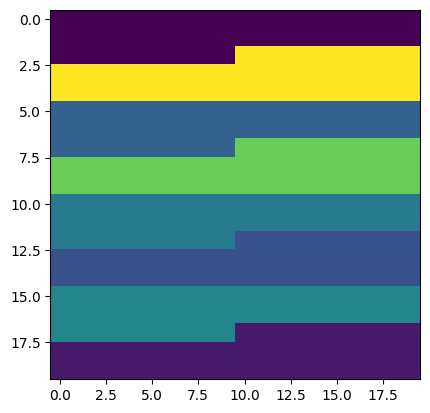

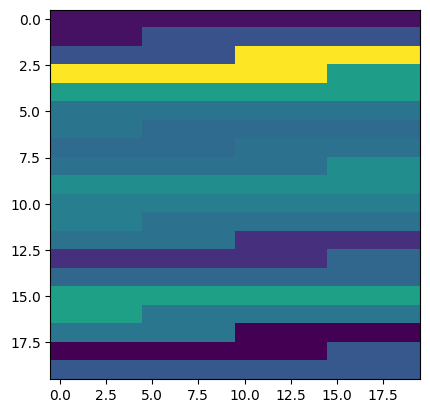

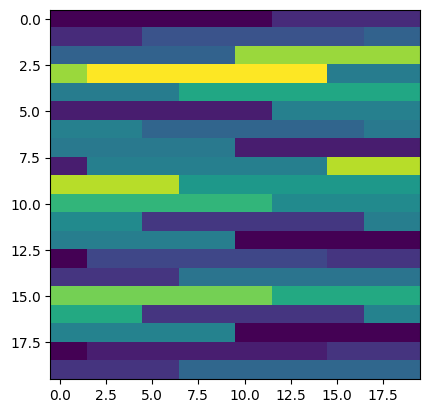

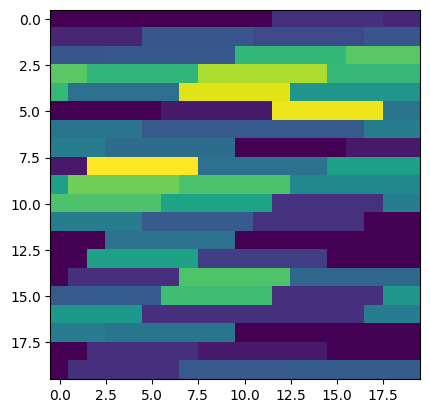

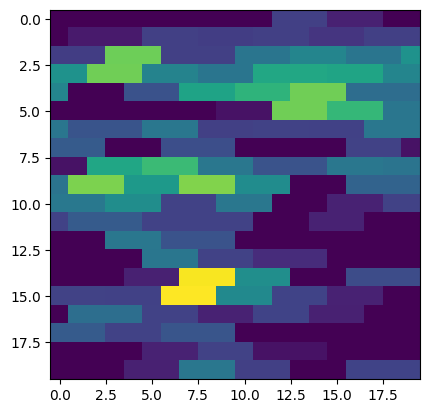

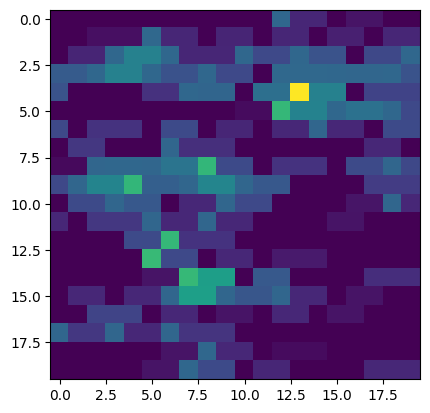

C:\Users\knano\AppData\Local\Temp\ipykernel_18492\3174782259.py:78: RuntimeWarning: divide by zero encountered in scalar divide
  self._score += 1 / np.sqrt(k)


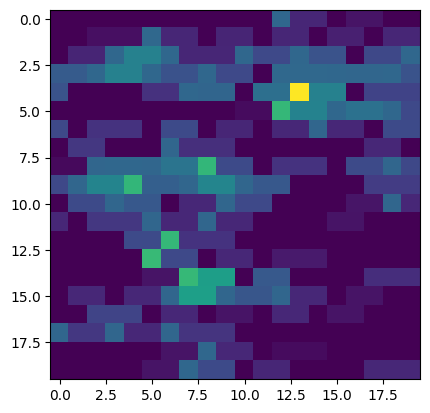

Done 1000000000


In [135]:
for div in [1, 2, 4, 8, 16, 32, 64, 128, 256]:
    num = int(N ** 2 / div / 2)
    for d in range(div):
        left = N ** 2 / div * d
        right = left + num
    
        all_coordinates_list = get_all_coordinate(env)
        all_coordinates = set(all_coordinates_list)
        sample_k = len(all_coordinates) // 4
        
        query_grids = set(all_coordinates_list[int(left):int(right)])
        not_query_grids = all_coordinates - query_grids

        remain_oil_num = env.total_oil_num
        for y in range(N):
            for x in range(N):
                if env.fixed_board[y][x] > 0:
                    remain_oil_num -= env.fixed_board[y][x]

        sample_sum = 0
        for y, x in query_grids:
            sample_sum += cnt_board[y][x]
        not_sample_sum = 0
        for y, x in not_query_grids:
            not_sample_sum += cnt_board[y][x]

        cnt = min(max(0.001, env.query2(query_grids)), remain_oil_num - 0.001)

        not_cnt = remain_oil_num - cnt

        for y, x in query_grids:
            cnt_board[y][x] *= cnt / sample_sum
        for y, x in not_query_grids:
            cnt_board[y][x] *= not_cnt / not_sample_sum
        
        max_grid = -1
        max_grid_coordinate = (-1, -1)
        for y, x in all_coordinates:
            if cnt_board[y][x] > max_grid:
                max_grid = cnt_board[y][x]
                max_grid_coordinate = (y, x)

        if env.is_ok():
            env.answer_from_board(env.fixed_board)
            break

    plt.imshow(cnt_board)
    plt.show()

print("Done", env.score)

In [136]:
env._score

inf

In [137]:
# SIMULATE_N = 1000

# for simulate_n in range(SIMULATE_N):
    
#     all_coordinates_list = get_all_coordinate(env)
#     all_coordinates = set(all_coordinates_list)
#     sample_k = len(all_coordinates) // 4
#     # sample_k = 10

#     # score_to_coordinate = []
#     # for y, x in all_coordinates:
#     #     s = cnt_board[y][x]
#     #     score_to_coordinate.append((s, (y, x)))
#     # left = random.randint(0, len(score_to_coordinate) - sample_k - 1)
#     # sample_score_to_coordinate = sorted(score_to_coordinate)[left:left+sample_k]

#     # query_grids = set()
#     # for _, (y, x) in sample_score_to_coordinate:
#     #     query_grids.add((y, x))
#     # not_query_grids = all_coordinates - query_grids
    
#     query_grids = set(random.sample(all_coordinates_list, sample_k))
#     not_query_grids = all_coordinates - query_grids

#     remain_oil_num = env.total_oil_num
#     for y in range(N):
#         for x in range(N):
#             if env.fixed_board[y][x] > 0:
#                 remain_oil_num -= env.fixed_board[y][x]

#     sample_sum = 0
#     for y, x in query_grids:
#         sample_sum += cnt_board[y][x]
#     not_sample_sum = 0
#     for y, x in not_query_grids:
#         not_sample_sum += cnt_board[y][x]

#     cnt = min(max(0.001, env.query2(query_grids)), remain_oil_num - 0.001)

#     not_cnt = remain_oil_num - cnt

#     for y, x in query_grids:
#         cnt_board[y][x] *= cnt / sample_sum
#     for y, x in not_query_grids:
#         cnt_board[y][x] *= not_cnt / not_sample_sum
    
#     max_grid = -1
#     max_grid_coordinate = (-1, -1)
#     for y, x in all_coordinates:
#         if cnt_board[y][x] > max_grid:
#             max_grid = cnt_board[y][x]
#             max_grid_coordinate = (y, x)

#     if env.is_ok():
#         env.answer_from_board(env.fixed_board)
#         break

#     if simulate_n % 1000 == 0:
#         print(simulate_n)
#         plt.imshow(cnt_board)
#         plt.show()
#     # if simulate_n >= 200 and simulate_n % 3 == 0:
#     #     resp = env.query1(max_grid_coordinate)
#     #     ry, rx = max_grid_coordinate
#     #     now_cnt = cnt_board[ry][rx]
#     #     avg_diff_cnt = (resp - now_cnt) / N**2
#     #     cnt_board[ry][rx] = resp
#     #     for y in range(N):
#     #         for x in range(N):
#     #             if (y, x) != max_grid_coordinate:
#     #                 cnt_board[ry][rx] += avg_diff_cnt
#     #     print(f"==={simulate_n}/{SIMULATE_N}===")

# print("Done", env.score)

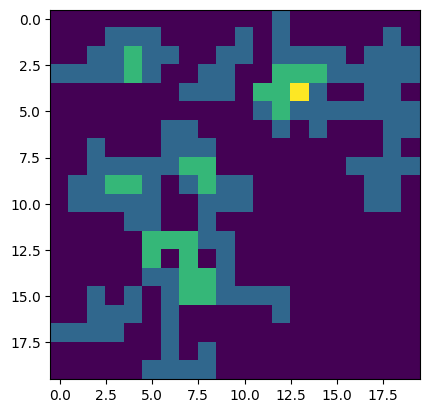

In [138]:
plt.imshow(env.ans_grid)
plt.show()

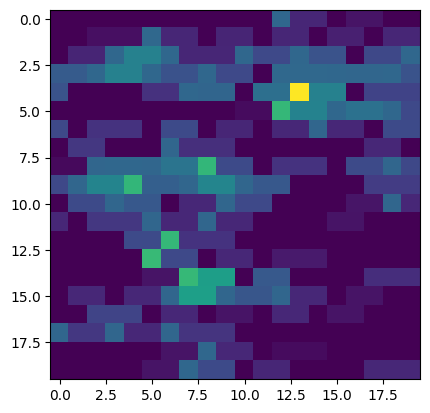

In [139]:
plt.imshow(cnt_board)
plt.show()

In [140]:
# SIMULATE_N = 1000

# for simulate_n in range(SIMULATE_N):

#     # query_grids = set()
#     # for m in range(M):
#     #     sample_index = random.choice(placement_indexes[m])
#     #     for coordinate in grids[m]:
#     #         cy, cx = coordinate
#     #         dy, dx = sample_index
#     #         query_grids.add((cy+dy, cx+dx))
#     # not_query_grids = all_coordinates - query_grids

#     # score_to_coordinate = []
#     # for y in range(N):
#     #     for x in range(N):
#     #         s = cnt_board[y][x]
#     #         score_to_coordinate.append((s, (y, x)))
#     # sample_score_to_coordinate = sorted(score_to_coordinate)[:sample_k]

#     # query_grids = set()
#     # for _, (y, x) in sample_score_to_coordinate:
#     #     query_grids.add((y, x))
#     # not_query_grids = all_coordinates - query_grids
    
#     query_grids = set(random.sample(all_coordinates_list, sample_k))
#     not_query_grids = all_coordinates - query_grids

#     sample_sum = 0
#     for y, x in query_grids:
#         sample_sum += cnt_board[y][x]
#     not_sample_sum = 0
#     for y, x in not_query_grids:
#         not_sample_sum += cnt_board[y][x]

#     cnt = min(max(0.001, env.query2(query_grids)), env.total_oil_num - 0.001)
#     # diff_cnt = sample_sum - cnt
#     # rate = (SIMULATE_N - simulate_n) / SIMULATE_N
#     # diff_cnt = diff_cnt * cnt
#     # update_cnt = sample_sum - diff_cnt

#     not_cnt = env.total_oil_num - cnt

#     for y, x in query_grids:
#         cnt_board[y][x] *= cnt / sample_sum
#     for y, x in not_query_grids:
#         cnt_board[y][x] *= not_cnt / not_sample_sum
    
#     if simulate_n % 100 == 0:
#         print(f"==={simulate_n}/{SIMULATE_N}===")
#         print(env._score)
#         plt.imshow(cnt_board)
#         plt.show()

In [141]:
# class Evaluator:

#     def __init__(self):
#         self.scores = []
#         self.ans_points = []
#         self.board_sizes = []

#     def add_result(self, score, ans_point, board_size):
#         self.scores.append(score)
#         self.ans_points.append(ans_point)
#         self.board_sizes.append(board_size)

In [142]:
# def solve(env: Env):
    
#     board_simulator = BoardSimulator(env)
#     for i in range(500):
#         if env.is_ok():
#             env.answer(env.plus_coordinates)
#             break
#         coordinate, ans_board = board_simulator.get_next_coordinate()
#         if ans_board is not None:
#             if env.answer_from_board(ans_board):
#                 break
#         resp = env.query1(coordinate)

In [143]:
# import random

# TEST_NUM = 1
# evaluator = Evaluator()

# def main():
#     random.seed(0)
#     for test_num in range(TEST_NUM):
#         print(f"===== {test_num+1}/{TEST_NUM} =====")
#         env = Env(file_path = Path(f"../in/{test_num:0>4}.txt"), exp_num=test_num)
#         solve(env)
#         evaluator.add_result(env.score, env.ans_point_size, env.N**2)
#         print(f"score:{env.score}")
# main()

# Evaluate

In [144]:
# import matplotlib.pyplot as plt
# import numpy as np

# plt.figure(figsize=(15, 5))
# x = list(range(TEST_NUM))
# plt.bar(x, evaluator.board_sizes, alpha=0.5)
# plt.bar(x, evaluator.scores)
# plt.bar(x, evaluator.ans_points, alpha=0.5)
# plt.plot(x, np.array(evaluator.scores) / np.array(evaluator.ans_points) * 100, marker="o")
# plt.xticks(range(0, len(evaluator.scores)+1, 5))
# plt.show()

# print(sum(evaluator.scores) / len(evaluator.scores))